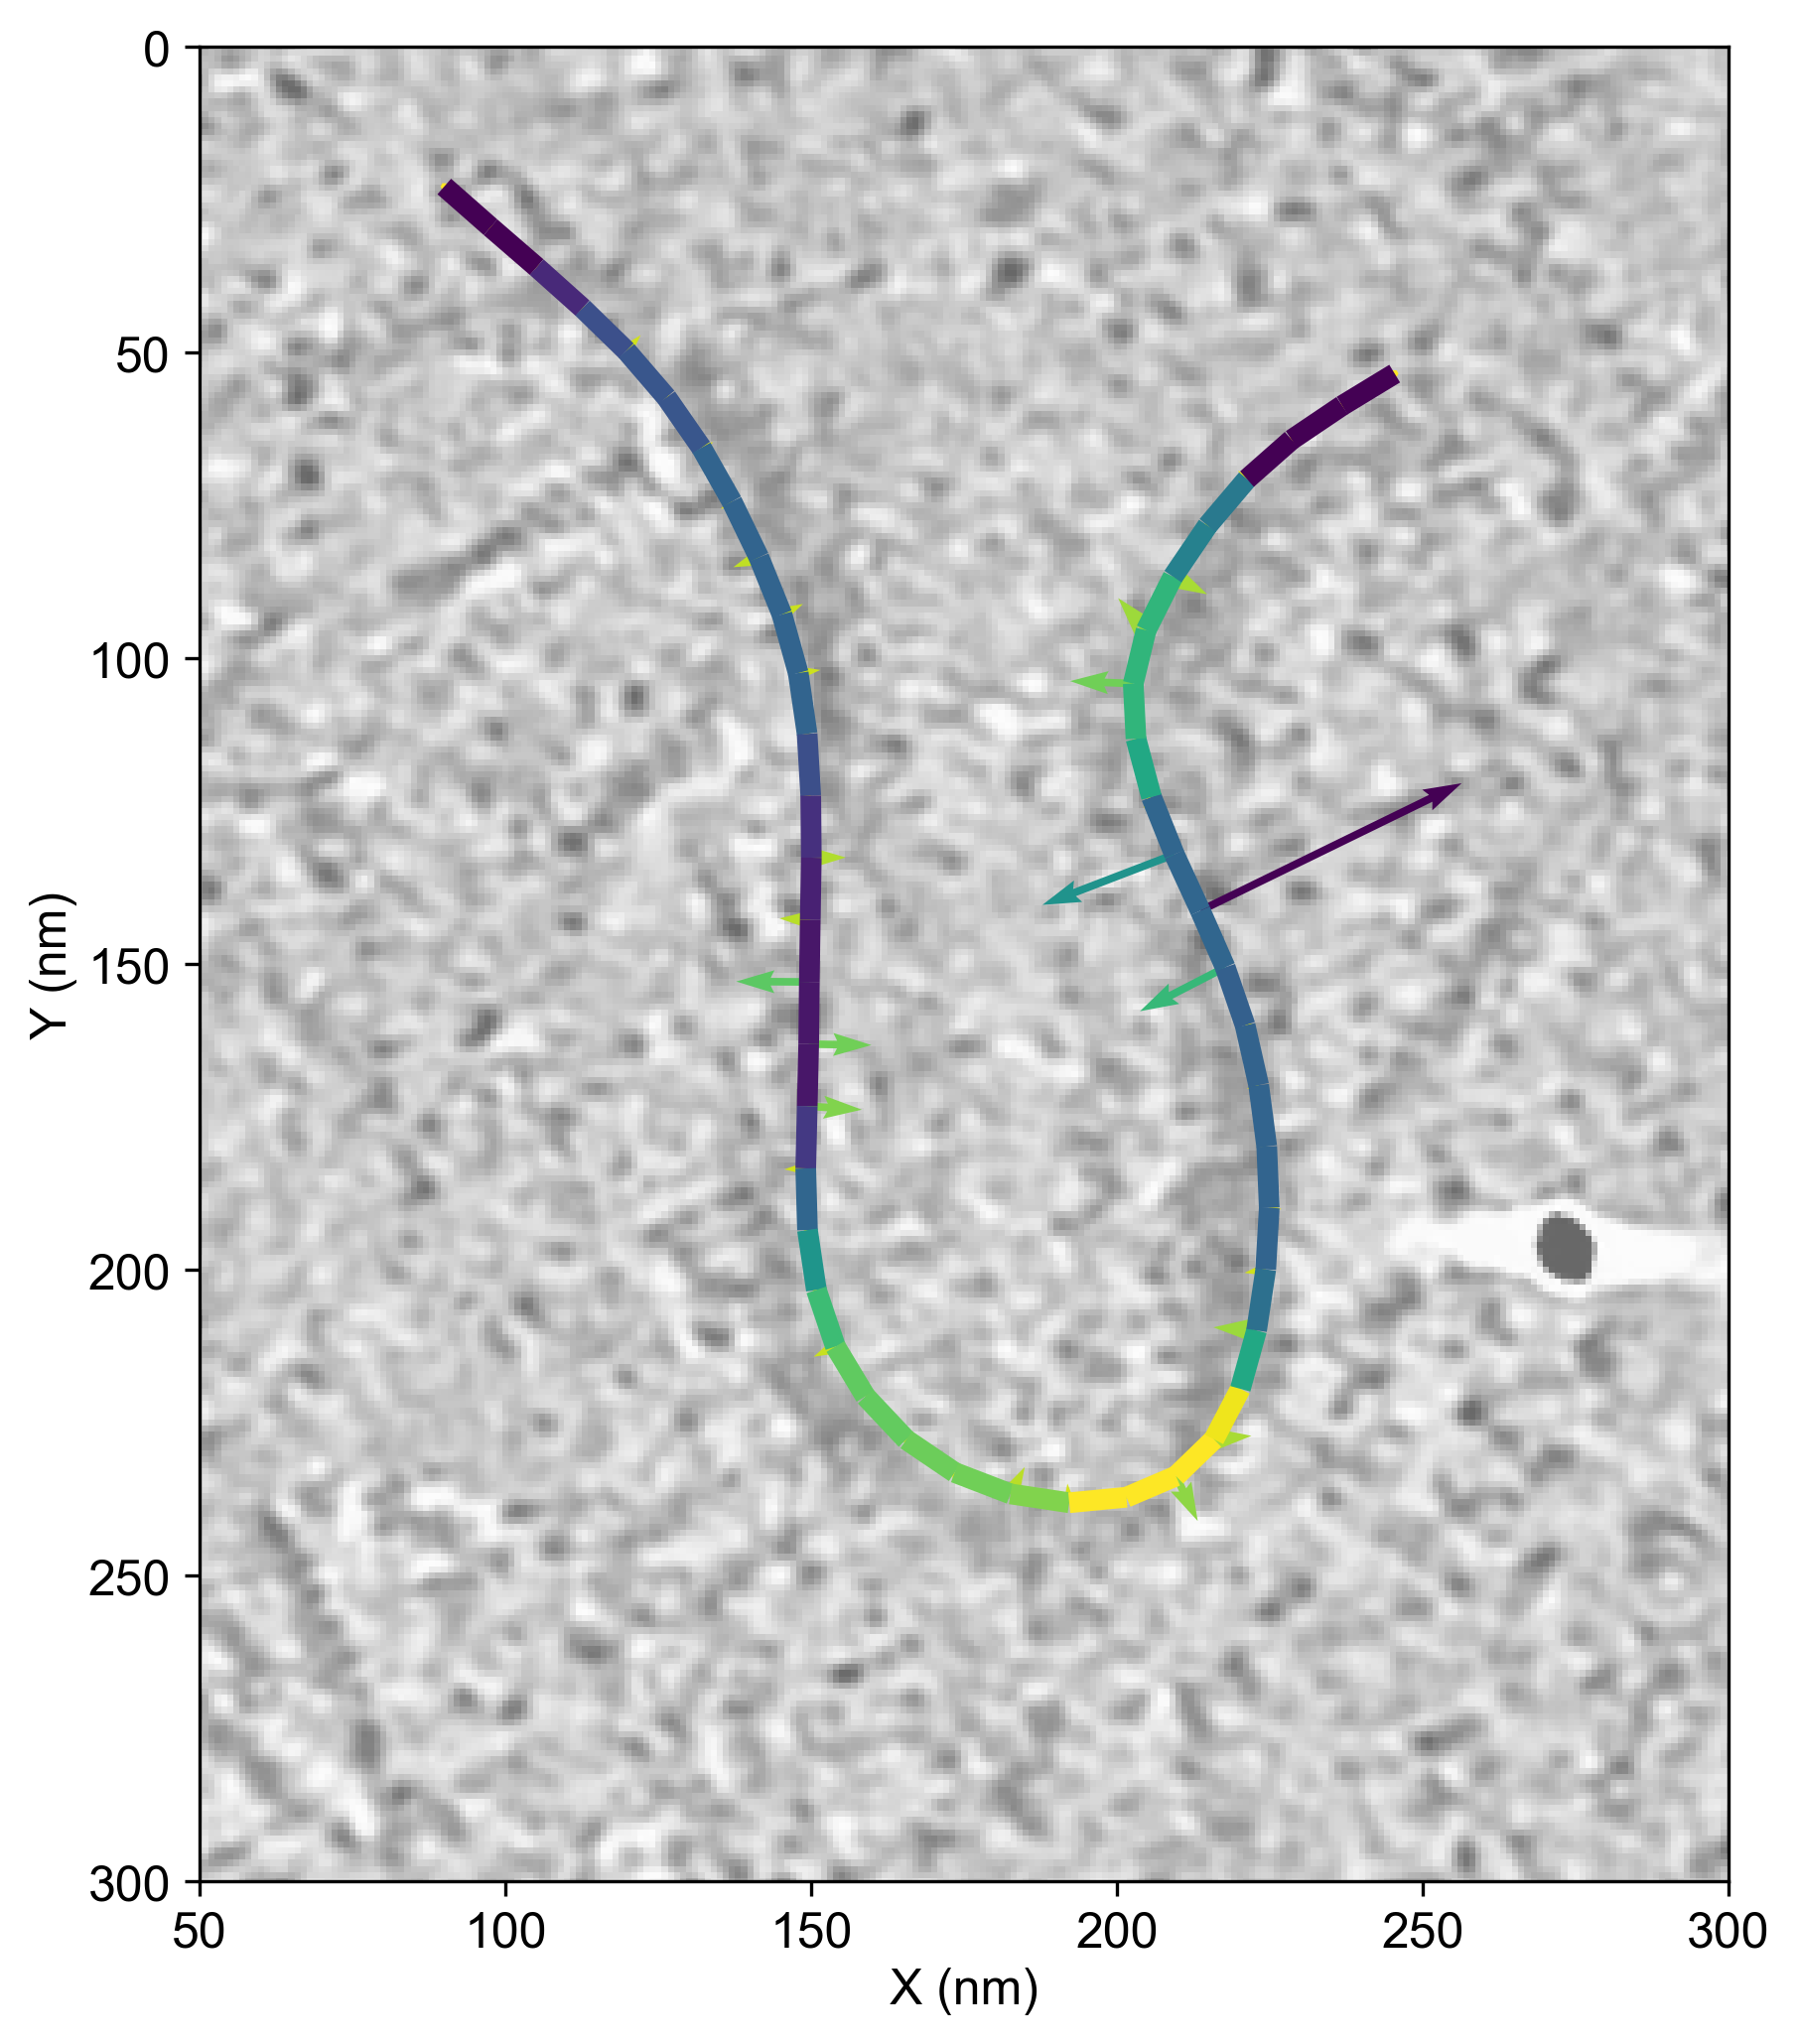

<Figure size 900x900 with 0 Axes>

In [1]:
import numpy as np
import numpy.typing as npt
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from variation_run import get_force_density, get_force
from automembrane.energy import OpenPlaneCurveMaterial
from automembrane.geometry import OpenPlaneCurveGeometry
from plot import load_image, shift_coords, resize_image, plot_coord_force, plot_coord_curve_force, plot_coord_curve_force_center
from scipy.signal import medfilt

# File and parameters setup
file = Path('coordinates/Membrane_2018June_Tomo26_CME_Invagination.txt')
N_fit = 3
parameters = {
    "Kb": 100/4,  # Bending modulus (pN um; original 1e-19 J)
    "Ksg": 0.5,  # Global stretching modulus (pN um/um^2; original 0.05 mN/m)
    "Ksl": 0,    # Regularization modulus (pN um; 0), 
    "boundary": "fixed", 
    "N_fit": N_fit
}

n_vertices = 50

# Load coordinates and forces
coords = np.load(f"dat/mesh_test/coords_n{n_vertices:03d}.npy")
forces = get_force_density(parameters, coords)
curves = OpenPlaneCurveGeometry.edge_curvature(coords, N_fit)
# center = OpenPlaneCurveGeometry.center_curvature(coords, N_fit)

# plot_coord_force(
#     file.stem, 
#     coords,
#     forces[0,],  # Use forces for either "bend" or "surf" depending on the row
#     xlim=(50, 300), 
#     ylim=(300, 0), 
#     scale_factor=0.001,
# )

plot_coord_curve_force(
    file.stem, 
    coords,
    curves,
    forces[0,],
    xlim=(50, 300), 
    ylim=(300, 0), 
    scale_factor=0.0005,
)


# Adjust layout for better spacing between plots
plt.tight_layout()
# plt.savefig(f"figures/mesh_test/test.png", dpi=300)
plt.show()




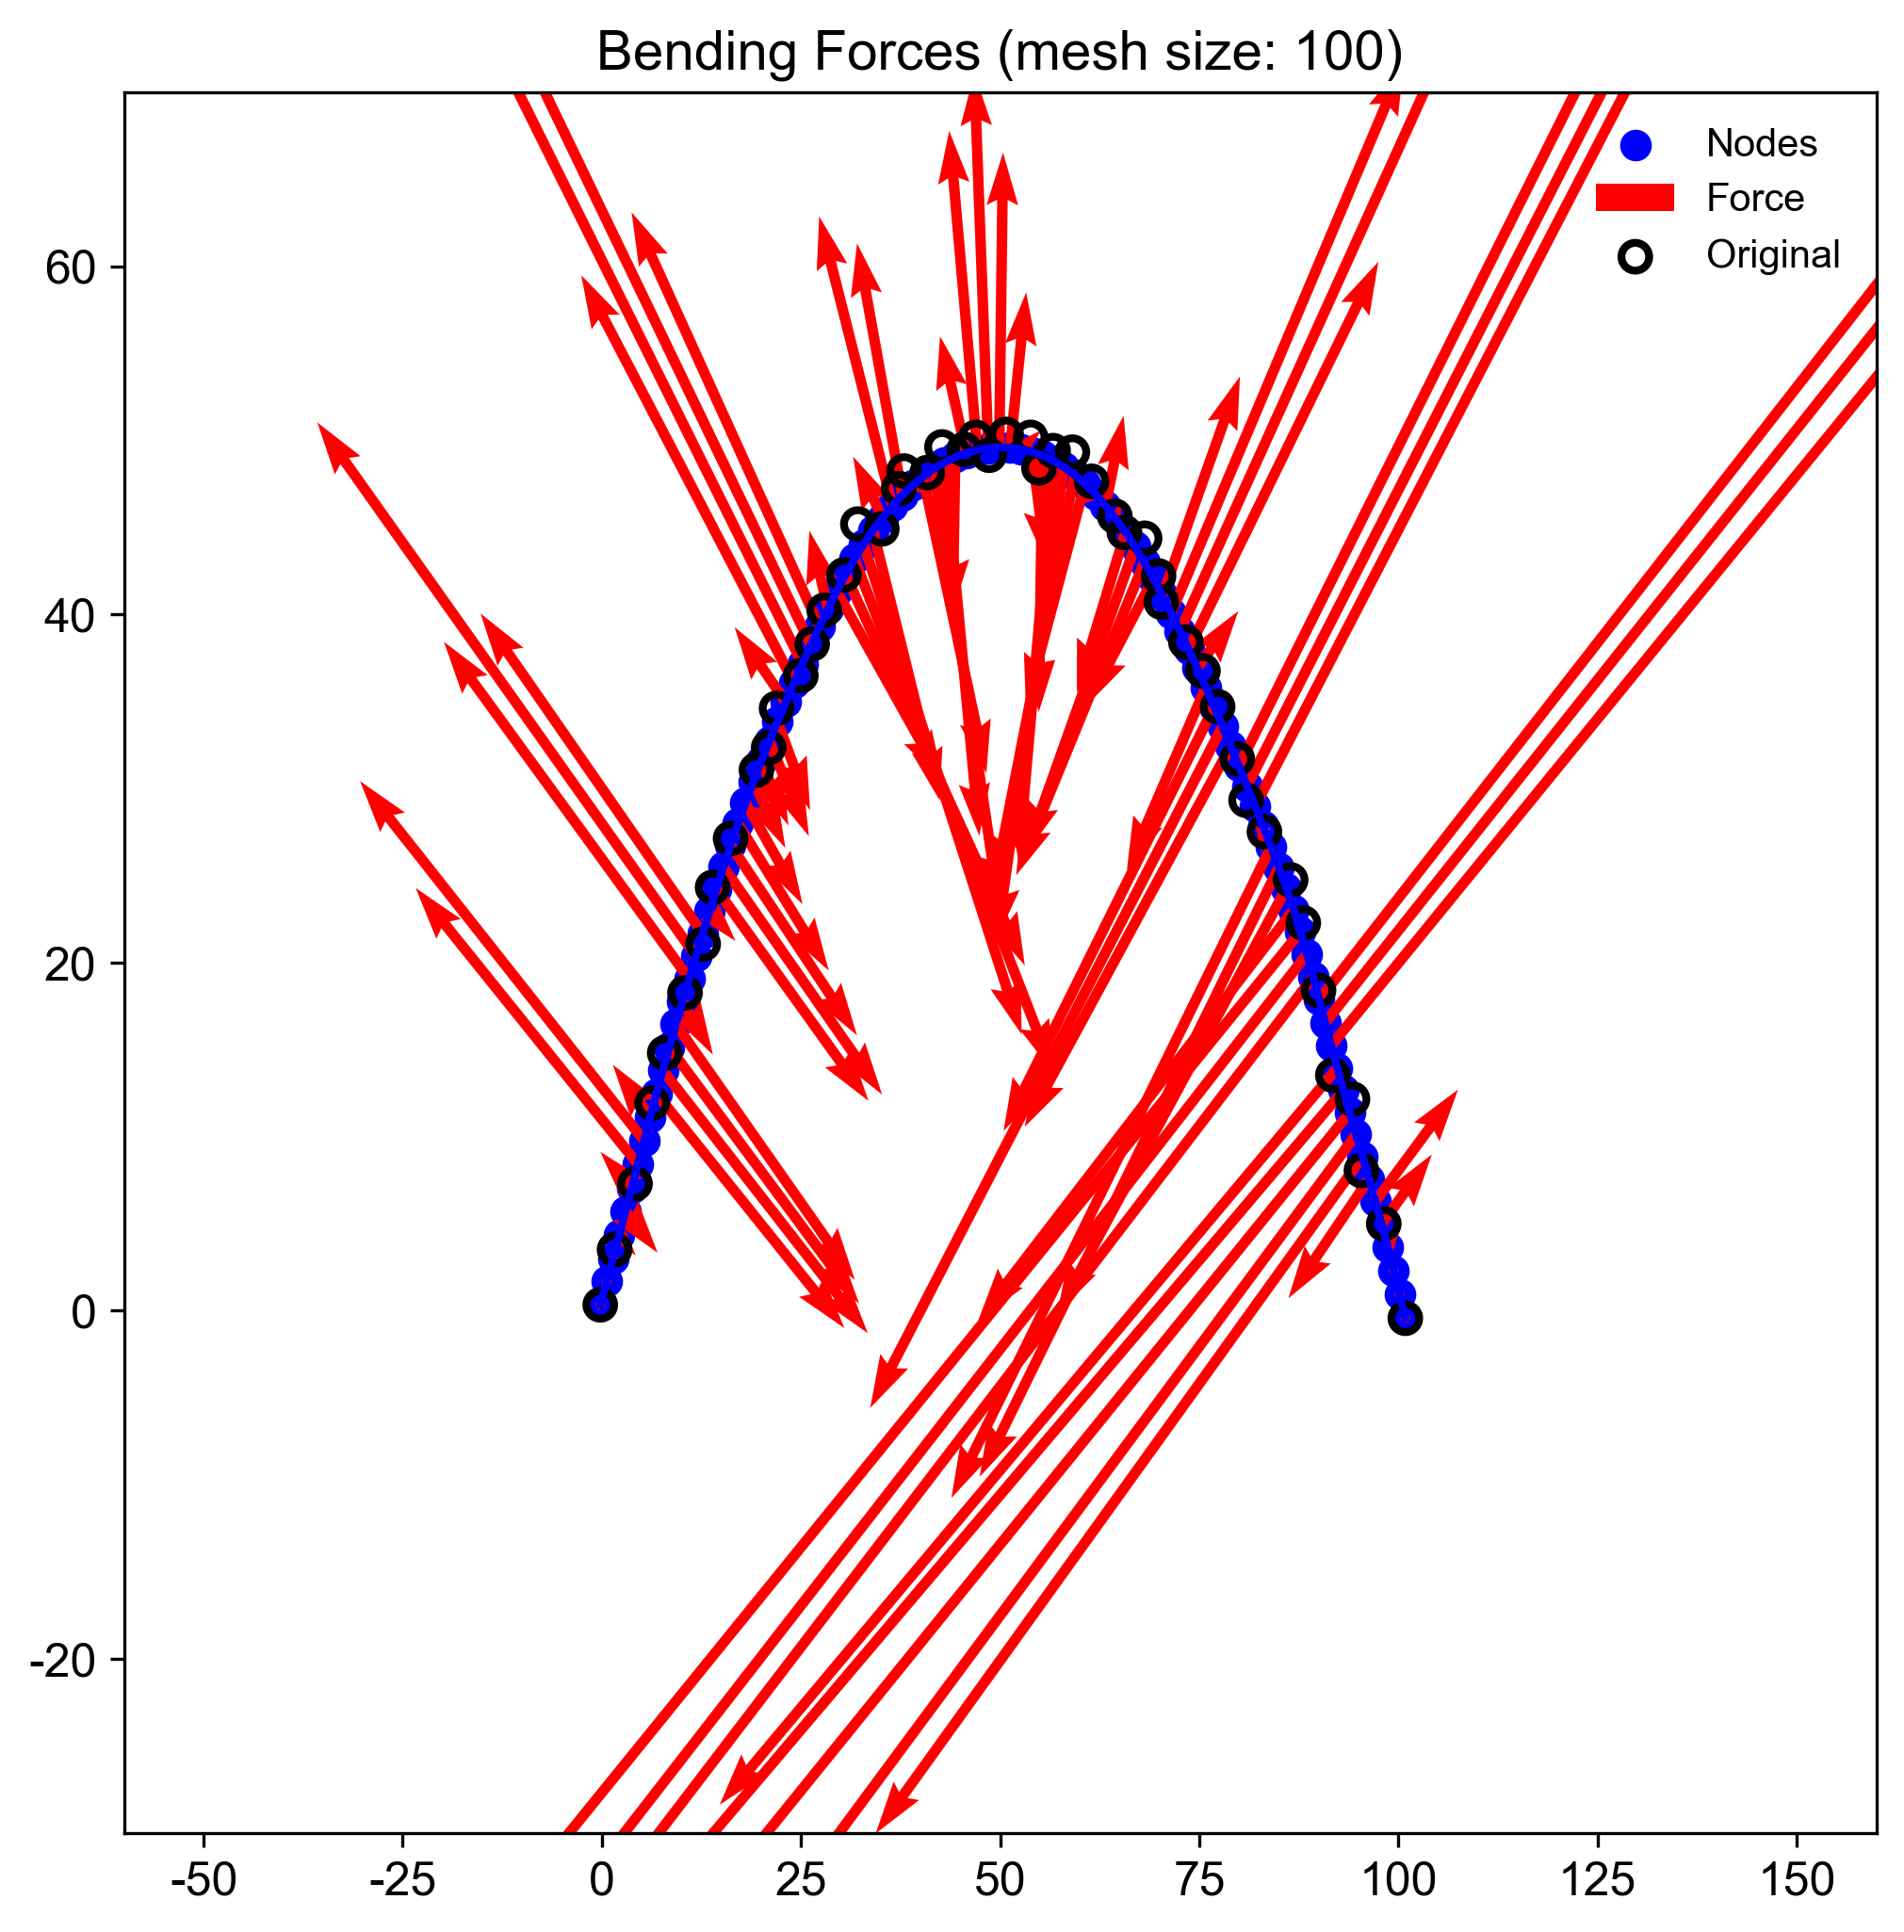

In [6]:
from variation_run import get_force_density
from sample import make_parabola, plot_parabola_ax
import os
import matplotlib.pyplot as plt
import numpy as np

parameters = {
    "Kb":  100 / 4,   # Bending modulus (pN nm)
    "Ksg": 0.5,    # Global stretching modulus (pN nm)
    "Ksl": 0,
    "boundary": "fixed",
    "N_fit": 8,
}

N_node = 50
noise_level = 0.5
n_vertices = 100

file_path = os.path.join(f"dat/mesh_test", f"noise_n{N_node}_{noise_level:.2f}".replace('.', '') + f"_n{n_vertices:03d}.npz")
data = np.load(file_path)
coords = data['coords']
ori_coords = data['ori_coords']
force = get_force_density(parameters, coords)
# force = get_force_density(parameters, ori_coords)

fig, ax = plt.subplots(figsize=(8, 8))
plot_parabola_ax(coords, force[0], ax=ax, mesh_size=n_vertices, force_type="Bending Forces", scale=50, ori_coords = ori_coords)

# plt.savefig(f"figures/mesh_test/force_dist_para_noise_n{N_node}.png", dpi=300)
plt.show()

In [8]:

plt.show()

[1, 2, 3, 4, 5, 6]
